# Lab 7

In [1]:
from IPython.display import display

from pathlib import Path

from sklearn import datasets
from sklearn import metrics as mt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from matplotlib import pyplot as plt
import seaborn as sns

import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow.keras as keras

from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Layer, GlobalAveragePooling1D
from tensorflow.keras import ops
from tensorflow.keras.saving import register_keras_serializable, load_model
from tensorflow.keras.utils import plot_model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers \
    import Activation, Conv2D, Dense, Dropout, Flatten, \
        Input, MaxPooling2D, RandomFlip, RandomRotation, Reshape

print('Tensorflow version:',tf.__version__)
print('Keras version:', keras.__version__)

print(tf.config.list_physical_devices('GPU'))

Tensorflow version: 2.20.0
Keras version: 3.12.0
[]


We used the [emotion detection from text](https://www.kaggle.com/datasets/pashupatigupta/emotion-detection-from-text) dataset on Kaggle to perform sentiment analysis on Tweets.

In [2]:
df = pd.read_csv("tweet_emotions.csv")

MAX_TWEET_LENGTH = df['content'].map(lambda x : x.count(" ")).max()
print(MAX_TWEET_LENGTH)

data = df['content']
np_target = df['sentiment']

df.head()

100


,tweet_id,sentiment,content
0,1956967341,empty,@tiffanylue i know i was listenin to bad habi...
1,1956967666,sadness,Layin n bed with a headache ughhhh...waitin o...
2,1956967696,sadness,Funeral ceremony...gloomy friday...
3,1956967789,enthusiasm,wants to hang out with friends SOON!
4,1956968416,neutral,@dannycastillo We want to trade with someone w...


In the unprocessed data, the `content` column contains the text data. In our dataset, the maximum tweet length is 100 words.

In [3]:
df["sentiment"].value_counts(normalize = True)

sentiment
neutral       0.215950
worry         0.211475
happiness     0.130225
sadness       0.129125
love          0.096050
surprise      0.054675
fun           0.044400
relief        0.038150
hate          0.033075
empty         0.020675
enthusiasm    0.018975
boredom       0.004475
anger         0.002750
Name: proportion, dtype: float64

Due to the heavy class imbalance (anger at 0.3% vs. neutral at 22%), we use the F1 score macro-averaged as a metric to more heavily punish always picking the plurality class.

In [4]:
target_unique = np.unique(np_target)
NUM_CLASSES = len(target_unique)
print(NUM_CLASSES)

le = LabelEncoder()
le.fit(target_unique)
labels = list(le.classes_)
target = le.transform(np_target)

print(labels)

13
['anger', 'boredom', 'empty', 'enthusiasm', 'fun', 'happiness', 'hate', 'love', 'neutral', 'relief', 'sadness', 'surprise', 'worry']


There are 13 sentiments in the `sentiment` column listed above.

In [5]:
NUM_TOP_WORDS = None # use entire vocabulary!
MAX_ART_LEN = 1000 # maximum and minimum number of words

#tokenize the text
tokenizer = Tokenizer(num_words=NUM_TOP_WORDS)
tokenizer.fit_on_texts(data)
# save as sequences with integers replacing words
sequences = tokenizer.texts_to_sequences(data)

word_index = tokenizer.word_index
NUM_TOP_WORDS = len(word_index) if NUM_TOP_WORDS==None else NUM_TOP_WORDS
top_words = min((len(word_index),NUM_TOP_WORDS))
print('Found %s unique tokens. Distilled to %d top words.' % (len(word_index),top_words))

X = pad_sequences(sequences, maxlen=MAX_ART_LEN)

y_ohe = keras.utils.to_categorical(target)
print('Shape of data tensor:', X.shape)
print('Shape of label tensor:', y_ohe.shape)
print(np.max(X))

Found 48997 unique tokens. Distilled to 48997 top words.
Shape of data tensor: (40000, 1000)
Shape of label tensor: (40000, 13)
48997


In [6]:
# Split it into train / test subsets
X_train, X_test, y_train_ohe, y_test_ohe = train_test_split(X, y_ohe, test_size=0.2,
                                                            stratify=target)

train_data = tf.data.Dataset.from_tensor_slices((X_train, y_train_ohe)).batch(64)
test_data = tf.data.Dataset.from_tensor_slices((X_test, y_test_ohe)).batch(64)
history = []

For this project, we decided to perform an 80/20 train/test split, stratified by the sentiment to ensure that minority classes are still included.

In [7]:
%%time
EMBED_SIZE = 100
# the embed size should match the file you load glove from
embeddings_index = {}
f = open('glove.6B.100d.txt', encoding = 'utf-8')
# save key/array pairs of the embeddings
#  the key of the dictionary is the word, the array is the embedding
for line in f:
    values = line.split()
    word = values[0]
    coefs = np.asarray(values[1:], dtype='float32')
    embeddings_index[word] = coefs
f.close()

print('Found %s word vectors.' % len(embeddings_index))

# now fill in the matrix, using the ordering from the
#  keras word tokenizer from before
found_words = 0
embedding_matrix = np.zeros((len(word_index) + 1, EMBED_SIZE))
for word, i in word_index.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        # words not found in embedding index will be ALL-ZEROS
        embedding_matrix[i] = embedding_vector
        found_words = found_words+1

print("Embedding Shape:", embedding_matrix.shape, "\n",
      "Total words found:", found_words, "\n",
      "Percentage:", 100 * found_words / embedding_matrix.shape[0])

Found 400000 word vectors.
Embedding Shape: (48998, 100) 
 Total words found: 22475 
 Percentage: 45.86921915180211
CPU times: user 4.76 s, sys: 208 ms, total: 4.96 s
Wall time: 5.07 s


In [8]:
def run_model(model, basename, train, test, batch, epochs, verbose):
    filename = Path("pretrain") / basename
    historyname = Path("history") / ("%s.npy" % basename)
    if filename.exists():
        model = load_model(filename)
        history = np.load(historyname, allow_pickle='TRUE').item()
        return model, history
        
    history = model.fit(train, validation_data = test, batch_size = batch,
        epochs = epochs, verbose = verbose, shuffle = True)
    model.save(filename)
    np.save(historyname, history.history)
    return model, history.history

In [9]:
from tensorflow.keras.layers import Embedding

# save this embedding now
embedding_layer = Embedding(len(word_index) + 1,
                            EMBED_SIZE,
                            weights=[embedding_matrix],# here is the embedding getting saved
                            trainable=False)

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM
from tensorflow.keras.metrics import F1Score

rnn = Sequential()
rnn.add(embedding_layer)
rnn.add(LSTM(100,dropout=0.2, recurrent_dropout=0.2))
rnn.add(Dense(NUM_CLASSES, activation='softmax'))
rnn.compile(loss='categorical_crossentropy', 
              optimizer='rmsprop', 
              metrics=[F1Score(average = 'macro')])
print(rnn.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     4,899,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,899,800 (18.69 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,899,800 (18.69 MB)

None


Here we train our first model, a recurrent neural network.

In [11]:
rnn, tmp = run_model(rnn, 'rnn.keras',
    train_data, test_data, 64, 6, True)
history.append( tmp )

Epoch 1/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 174s 343ms/step - f1_score: 0.0971 - loss: 2.0718 - val_f1_score: 0.1125 - val_loss: 1.9863
Epoch 2/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 164s 329ms/step - f1_score: 0.1211 - loss: 1.9775 - val_f1_score: 0.1270 - val_loss: 1.9381
Epoch 3/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 167s 334ms/step - f1_score: 0.1342 - loss: 1.9318 - val_f1_score: 0.1352 - val_loss: 1.9163
Epoch 4/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 165s 329ms/step - f1_score: 0.1478 - loss: 1.9016 - val_f1_score: 0.1613 - val_loss: 1.8999
Epoch 5/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 167s 335ms/step - f1_score: 0.1585 - loss: 1.8817 - val_f1_score: 0.1652 - val_loss: 1.8951
Epoch 6/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 165s 330ms/step - f1_score: 0.1678 - loss: 1.8632 - val_f1_score: 0.1674 - val_loss: 1.8907


In [12]:
# Keras 3 version from https://keras.io/examples/nlp/text_classification_with_transformer/

@register_keras_serializable()
class TransformerBlock(Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1, **kwargs):
        super().__init__(**kwargs)
        # setup the model heads and feedforward network
        # these setup handles to the operations we will use 
        # we have NOT yet setup any calls to add these operations to
        # the computation graph. Because we predict from the sequence
        # there is no need to use causal masking.
        self.att = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        # make a two layer network that can process the attention
        self.ffn = Sequential(
            [Dense(ff_dim, activation="relu"),
            Dense(embed_dim),
            ]
        )
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs):
        # inputs:  keras tensor, tensors that need operations applied
        # training: boolean, are we in training mode?
        # apply the layers as needed (similar to PyTorch)
        
        # get the attention output from multi heads
        # Using same inpout here is self-attention
        # call inputs are (query, value, key) 
        # if only two inputs given, value and key are assumed the same
        attn_output = self.att(inputs, inputs)
        # create residual output, with attention
        attn_output = self.dropout1(attn_output)
        # apply dropout if training
        out1 = self.layernorm1(inputs + attn_output)
        # place through feed forward after layer norm
        ffn_output = self.ffn(out1)
        # apply dropout if training
        ffn_output = self.dropout2(ffn_output)
        #return the residual from Dense layer
        return self.layernorm2(out1 + ffn_output)

@register_keras_serializable()
class TokenAndPositionEmbedding(Layer):
    def __init__(self, maxlen, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        # create two embeddings 
        # one for processing the tokens (words)
        self.token_emb = Embedding(input_dim=vocab_size, output_dim=embed_dim)
        # another embedding for processing the position
        self.pos_emb = Embedding(input_dim=maxlen, output_dim=embed_dim)

    def call(self, x):
        # create a static position measure (input)
        maxlen = ops.shape(x)[-1]
        positions = ops.arange(start=0, stop=maxlen, step=1)
        # positions now goes from 0 to 500 (for IMdB) by 1
        # embed these positions
        positions = self.pos_emb(positions)
        # embed the tokens
        x = self.token_emb(x)
        # add embeddngs to get final embedding
        return x + positions


In [13]:
from tensorflow.keras import Model

embed_dim = 32  # Embedding size for each token
num_heads = 2  # Number of attention heads
ff_dim = 32  # Hidden layer size in feed forward network inside transformer

inputs = Input(shape=(X_train.shape[1],))
x = TokenAndPositionEmbedding(X_train.shape[1], top_words + 1, embed_dim)(inputs)
x = TransformerBlock(embed_dim, num_heads, ff_dim)(x)

x = GlobalAveragePooling1D()(x)
x = Dropout(0.2)(x)
x = Dense(20, activation='relu')(x)
x = Dropout(0.2)(x)
outputs = Dense(NUM_CLASSES, activation='softmax',
              kernel_initializer='glorot_uniform')(x)

model_xformer = Model(inputs=inputs, outputs=outputs)
print(model_xformer.summary())


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding    │ (None, 1000, 32)       │     1,599,936 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 1000, 32)       │        10,656 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 20)             │           660 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 13)             │           273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,611,525 (6.15 MB)

 Trainable params: 1,611,525 (6.15 MB)

 Non-trainable params: 0 (0.00 B)

None


Next, we train our second model, a transformer architecture.

In [14]:
model_xformer.compile(optimizer='adam', 
                      loss='categorical_crossentropy', 
                      metrics=[F1Score(average = 'macro')])

In [15]:
model_xformer, tmp = run_model(model_xformer, 'model_xformer.keras',
    train_data, test_data, 64, 6, True)
history.append( tmp )

Epoch 1/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 382s 758ms/step - f1_score: 0.0645 - loss: 2.2281 - val_f1_score: 0.0755 - val_loss: 2.0926
Epoch 2/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 381s 761ms/step - f1_score: 0.0904 - loss: 2.0947 - val_f1_score: 0.0936 - val_loss: 2.0476
Epoch 3/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 381s 763ms/step - f1_score: 0.1155 - loss: 1.9725 - val_f1_score: 0.1143 - val_loss: 2.0484
Epoch 4/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 380s 760ms/step - f1_score: 0.1577 - loss: 1.7716 - val_f1_score: 0.1265 - val_loss: 2.2980
Epoch 5/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 378s 757ms/step - f1_score: 0.2092 - loss: 1.5450 - val_f1_score: 0.1320 - val_loss: 2.5030
Epoch 6/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 383s 767ms/step - f1_score: 0.2733 - loss: 1.3194 - val_f1_score: 0.1361 - val_loss: 2.9244


In [16]:
from tensorflow.keras import Model

embed_dim = 32  # Embedding size for each token
num_heads = 8  # Number of attention heads, THIS IS WHAT I MODIFIED
ff_dim = 32  # Hidden layer size in feed forward network inside transformer

inputs = Input(shape=(X_train.shape[1],))
x = TokenAndPositionEmbedding(X_train.shape[1], top_words + 1, embed_dim)(inputs)
x = TransformerBlock(embed_dim, num_heads, ff_dim)(x)

x = GlobalAveragePooling1D()(x)
x = Dropout(0.2)(x)
x = Dense(20, activation='relu')(x)
x = Dropout(0.2)(x)
outputs = Dense(NUM_CLASSES, activation='softmax',
              kernel_initializer='glorot_uniform')(x)

model_xformer_mod = Model(inputs=inputs, outputs=outputs)
print(model_xformer_mod.summary())


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding_1  │ (None, 1000, 32)       │     1,599,936 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 1000, 32)       │        35,808 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 20)             │           660 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 13)             │           273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,636,677 (6.24 MB)

 Trainable params: 1,636,677 (6.24 MB)

 Non-trainable params: 0 (0.00 B)

None


In [17]:
model_xformer_mod.compile(optimizer='adam', 
                      loss='categorical_crossentropy', 
                      metrics=[F1Score(average = 'macro')])

In [18]:
model_xformer_mod, tmp = run_model(model_xformer_mod, 'model_xformer_mod.keras',
    train_data, test_data, 64, 1, True)
history.append( tmp )

/opt/homebrew/lib/python3.13/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'token_and_position_embedding_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/opt/homebrew/lib/python3.13/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'transformer_block_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Next, we train our third model, a modified transformer.

In [19]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GlobalAveragePooling1D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.layers import Embedding, Input, Concatenate
from tensorflow.keras.layers import Subtract
from tensorflow.keras.utils import plot_model

EMBED_SIZE = 50
# the input is a list of integers, 500 long
sequence_input = Input(shape=(X_train.shape[1], ))

# this will reduce the input dimension from VOCAB_SIZE to 50 for each word
# the lenght will be the maximum number of words in a document, so 500
embedded_sequences = Embedding(top_words + 1, # input dimension (max int of OHE)
                EMBED_SIZE, # output dimension size
                input_length=MAX_TWEET_LENGTH)(sequence_input) # number of words in each sequence

# starting sequence size is 500 (words) by 50 (embedded features)
x = Conv1D(64, 5, activation='relu',
           kernel_initializer='he_uniform')(embedded_sequences)

# after conv, length becomes: 500-4=496 
# so overall size is 496 by 64

# now pool across time
x = MaxPooling1D(5)(x)# after max pool, 496/5 -> 99 by 64
x = Dropout(0.2)(x)

# extract additional features
x = Conv1D(64, 5, activation='relu',
           kernel_initializer='he_uniform')(x)

# new size is 95 after the conovlutions
x = MaxPooling1D(5)(x) # after max pool, size is 95/5 = 19 by 64
x = Dropout(0.2)(x)

# more features through CNN processing!
x = Conv1D(64, 5, activation='relu',
           kernel_initializer='he_uniform')(x)
x = Dropout(0.2)(x)

# after convolution, size becomes 15 elements long
# Take the mean of these elements across features, result is 64 elements
x_mean = GlobalAveragePooling1D()(x) # this is the size to globally flatten 

# Take the variance of these elements across features, result is 64 elements
x_tmp = Subtract()([x,x_mean])
x_std = GlobalAveragePooling1D()(x_tmp**2)

x = Concatenate(name='concat_1')([x_mean,x_std])

x = Dense(64, activation='relu',
          kernel_initializer='he_uniform')(x)

x = Dropout(0.2)(x)

preds = Dense(NUM_CLASSES, activation='sigmoid',
              kernel_initializer='glorot_uniform')(x)

model_cnn = Model(sequence_input, preds)

print(model_cnn.summary())

/opt/homebrew/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 1000)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_7         │ (None, 1000, 50)  │  2,449,900 │ input_layer_6[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 996, 64)   │     16,064 │ embedding_7[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 199, 64)   │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 199, 64)   │          0 │ max_pooling1d[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 195, 64)   │     20,544 │ dropout_13[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 39, 64)    │          0 │ conv1d_1[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 39, 64)    │          0 │ max_pooling1d_1[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 35, 64)    │     20,544 │ dropout_14[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 35, 64)    │          0 │ conv1d_2[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ dropout_15[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract (Subtract) │ (None, 35, 64)    │          0 │ dropout_15[0][0], │
│                     │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ power (Power)       │ (None, 35, 64)    │          0 │ subtract[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ power[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_1            │ (None, 128)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 64)        │      8,256 │ concat_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 64)        │          0 │ dense_11[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 13)        │        845 │ dropout_16[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,516,153 (9.60 MB)

 Trainable params: 2,516,153 (9.60 MB)

 Non-trainable params: 0 (0.00 B)

None


In [20]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay


lr_schedule = ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=10000,
    decay_rate=0.95,
    staircase=True)  

opt = Adam(epsilon=0.0001, learning_rate=lr_schedule)
model_cnn.compile(loss='categorical_crossentropy',
              optimizer=opt,
              metrics=[F1Score(average = 'macro')])

Here we train our fourth model, a convolutional neural network.

In [21]:
model_cnn, tmp = run_model(model_cnn, 'model_cnn.keras',
    train_data, test_data, 64, 6, True)
history.append( tmp )

Epoch 1/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 53ms/step - f1_score: 0.0535 - loss: 2.1828 - val_f1_score: 0.0273 - val_loss: 2.1629
Epoch 2/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 24s 48ms/step - f1_score: 0.0463 - loss: 2.1588 - val_f1_score: 0.0273 - val_loss: 2.1502
Epoch 3/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 25s 50ms/step - f1_score: 0.0456 - loss: 2.1558 - val_f1_score: 0.0269 - val_loss: 2.1454
Epoch 4/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 27s 53ms/step - f1_score: 0.0457 - loss: 2.1529 - val_f1_score: 0.0269 - val_loss: 2.1455
Epoch 5/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step - f1_score: 0.0451 - loss: 2.1512 - val_f1_score: 0.0269 - val_loss: 2.1453
Epoch 6/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 24s 48ms/step - f1_score: 0.0454 - loss: 2.1503 - val_f1_score: 0.0273 - val_loss: 2.1452


In [22]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GlobalAveragePooling1D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.layers import Embedding, Input, Concatenate
from tensorflow.keras.layers import Subtract
from tensorflow.keras.utils import plot_model

EMBED_SIZE = 50
# the input is a list of integers, 500 long
sequence_input = Input(shape=(X_train.shape[1], ))

# this will reduce the input dimension from VOCAB_SIZE to 50 for each word
# the lenght will be the maximum number of words in a document, so 500
embedded_sequences = Embedding(top_words + 1, # input dimension (max int of OHE)
                EMBED_SIZE, # output dimension size
                input_length=MAX_TWEET_LENGTH)(sequence_input) # number of words in each sequence

# starting sequence size is 500 (words) by 50 (embedded features)
x = Conv1D(64, 3, activation='relu',
           kernel_initializer='he_uniform')(embedded_sequences)
#Here I changed te=he kernel size to 3

# after conv, length becomes: 500-4=496 
# so overall size is 496 by 64

# now pool across time
x = MaxPooling1D(5)(x)# after max pool, 496/5 -> 99 by 64
x = Dropout(0.2)(x)

# extract additional features
x = Conv1D(64, 5, activation='relu',
           kernel_initializer='he_uniform')(x)

# new size is 95 after the conovlutions
x = MaxPooling1D(5)(x) # after max pool, size is 95/5 = 19 by 64
x = Dropout(0.2)(x)

# more features through CNN processing!
x = Conv1D(64, 5, activation='relu',
           kernel_initializer='he_uniform')(x)
x = Dropout(0.2)(x)

# after convolution, size becomes 15 elements long
# Take the mean of these elements across features, result is 64 elements
x_mean = GlobalAveragePooling1D()(x) # this is the size to globally flatten 

# Take the variance of these elements across features, result is 64 elements
x_tmp = Subtract()([x,x_mean])
x_std = GlobalAveragePooling1D()(x_tmp**2)

x = Concatenate(name='concat_1')([x_mean,x_std])

x = Dense(64, activation='relu',
          kernel_initializer='he_uniform')(x)

x = Dropout(0.2)(x)

preds = Dense(NUM_CLASSES, activation='sigmoid',
              kernel_initializer='glorot_uniform')(x)

model_cnn_tuned = Model(sequence_input, preds)

print(model_cnn_tuned.summary())

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 1000)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_8         │ (None, 1000, 50)  │  2,449,900 │ input_layer_7[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 998, 64)   │      9,664 │ embedding_8[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 199, 64)   │          0 │ conv1d_3[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 199, 64)   │          0 │ max_pooling1d_2[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 195, 64)   │     20,544 │ dropout_17[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_3     │ (None, 39, 64)    │          0 │ conv1d_4[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_18          │ (None, 39, 64)    │          0 │ max_pooling1d_3[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 35, 64)    │     20,544 │ dropout_18[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_19          │ (None, 35, 64)    │          0 │ conv1d_5[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ dropout_19[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract_1          │ (None, 35, 64)    │          0 │ dropout_19[0][0], │
│ (Subtract)          │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ power_1 (Power)     │ (None, 35, 64)    │          0 │ subtract_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ power_1[0][0]     │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_1            │ (None, 128)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 64)        │      8,256 │ concat_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_20          │ (None, 64)        │          0 │ dense_13[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 13)        │        845 │ dropout_20[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,509,753 (9.57 MB)

 Trainable params: 2,509,753 (9.57 MB)

 Non-trainable params: 0 (0.00 B)

None


In [23]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay


lr_schedule = ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=10000,
    decay_rate=0.95,
    staircase=True)  

opt = Adam(epsilon=0.0001, learning_rate=lr_schedule)
model_cnn_tuned.compile(loss='categorical_crossentropy',
              optimizer=opt,
              metrics=[F1Score(average = 'macro')])

Now, we train our fifth model, a modified convolutional neural network.

In [24]:
model_cnn_tuned, tmp = run_model(model_cnn_tuned, 'model_cnn_tuned.keras',
    train_data, test_data, 64, 6, True)
history.append( tmp )

Epoch 1/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 40ms/step - f1_score: 0.0486 - loss: 2.1806 - val_f1_score: 0.0273 - val_loss: 2.1766
Epoch 2/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - f1_score: 0.0452 - loss: 2.1585 - val_f1_score: 0.0273 - val_loss: 2.1586
Epoch 3/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - f1_score: 0.0455 - loss: 2.1537 - val_f1_score: 0.0273 - val_loss: 2.1480
Epoch 4/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - f1_score: 0.0463 - loss: 2.1523 - val_f1_score: 0.0273 - val_loss: 2.1464
Epoch 5/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - f1_score: 0.0453 - loss: 2.1513 - val_f1_score: 0.0273 - val_loss: 2.1460
Epoch 6/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - f1_score: 0.0455 - loss: 2.1511 - val_f1_score: 0.0273 - val_loss: 2.1455


250/250 ━━━━━━━━━━━━━━━━━━━━ 17s 65ms/step
250/250 ━━━━━━━━━━━━━━━━━━━━ 32s 128ms/step
250/250 ━━━━━━━━━━━━━━━━━━━━ 110s 441ms/step
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


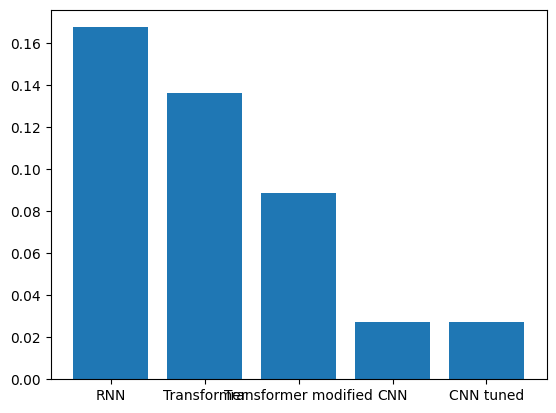

In [25]:
y_test_argmax = np.argmax(y_test_ohe, axis = 1)

models = [rnn, model_xformer, model_xformer_mod, model_cnn, model_cnn_tuned]
model_names = ["RNN", "Transformer", "Transformer modified", "CNN", "CNN tuned"]
ticks = range(1, len(models) + 1)

yhats = []
yhat_argmaxs = []
metrics = []

def process_model(m):
    yhat = m.predict(X_test)
    yhat_argmax = np.argmax(yhat, axis = 1)
    metric = mt.f1_score(y_test_argmax, yhat_argmax, average = 'macro')
    return (yhat, yhat_argmax, metric)

for m in models:
    yhat, yhat_argmax, metric = process_model(m)

    yhats.append(yhat)
    yhat_argmaxs.append(yhat_argmax)
    metrics.append(metric)

plt.bar(ticks, metrics)
plt.xticks(ticks, model_names)
plt.show()

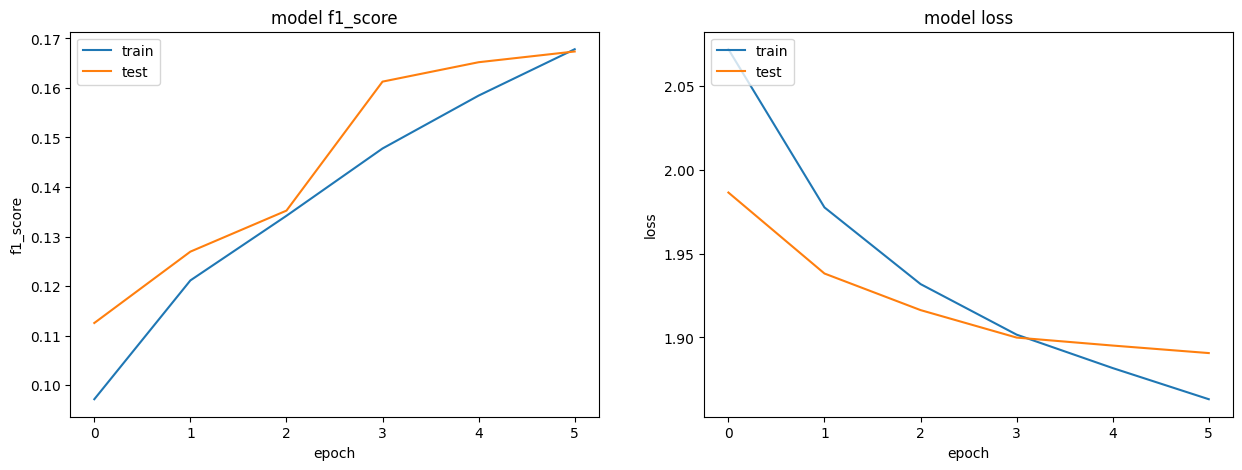

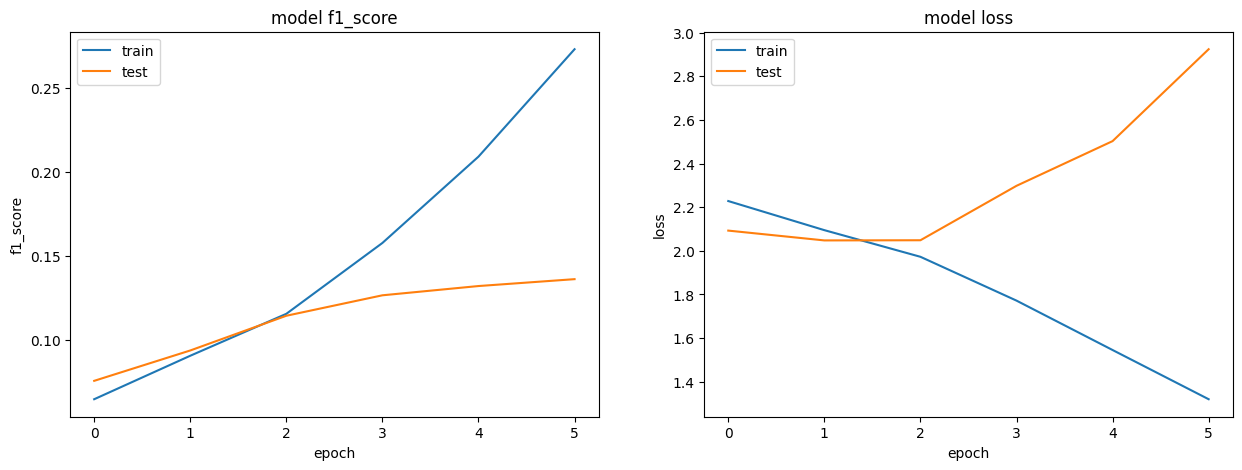

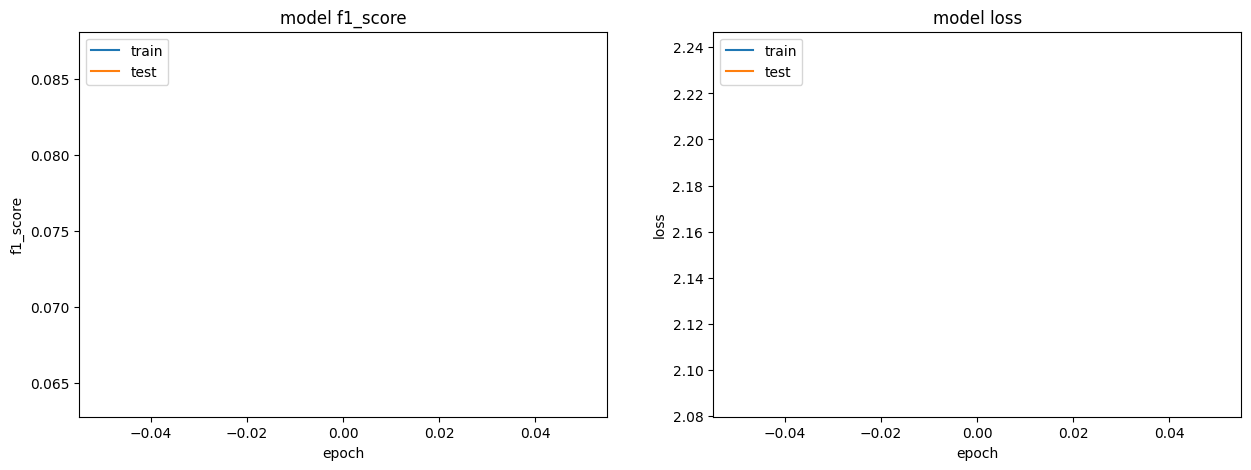

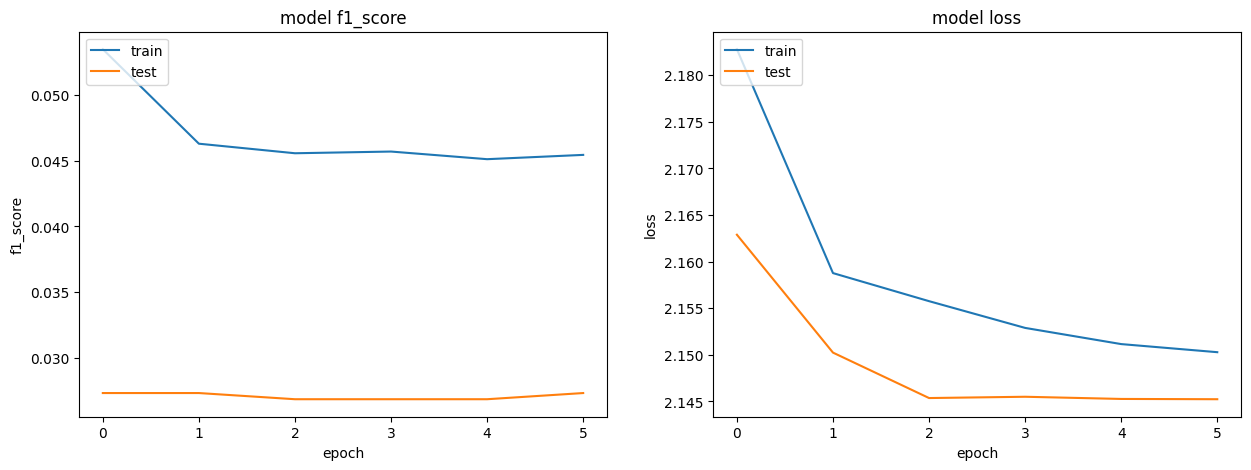

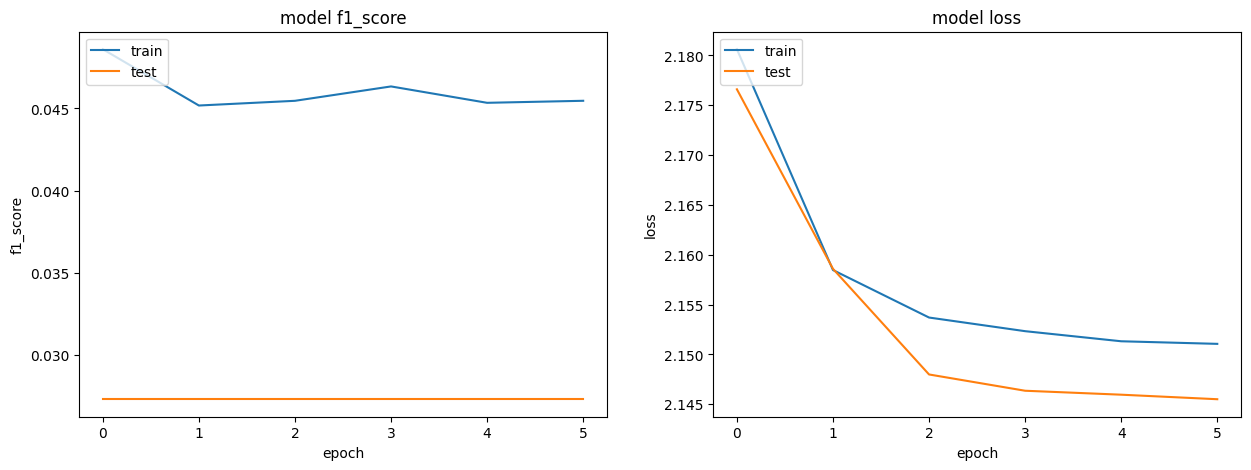

In [26]:
from sklearn import metrics as mt
from matplotlib import pyplot as plt
%matplotlib inline

metric_name = 'f1_score'
metric_val = 'val_' + metric_name

for combined in history:
    # summarize history for metric
    plt.figure(figsize=(15,5))
    plt.subplot(121)
    plt.plot(combined[metric_name])
    plt.plot(combined[metric_val])
    plt.title('model %s' % metric_name)
    plt.ylabel(metric_name)
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='upper left')

    # summarize history for loss
    plt.subplot(122)
    plt.plot(combined['loss'])
    plt.plot(combined['val_loss'])
    plt.title('model loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='upper left')
    plt.show()

In [27]:
from tensorflow.keras import Model

embed_dim = 32  # Embedding size for each token
num_heads = 2  # Number of attention heads
ff_dim = 32  # Hidden layer size in feed forward network inside transformer

inputs = Input(shape=(X_train.shape[1],))
x = TokenAndPositionEmbedding(X_train.shape[1], top_words + 1, embed_dim)(inputs)
# First attention layers
x = TransformerBlock(embed_dim, num_heads, ff_dim)(x)
# Second attention layers
x = TransformerBlock(embed_dim, num_heads, ff_dim)(x)

x = GlobalAveragePooling1D()(x)
x = Dropout(0.2)(x)
x = Dense(20, activation='relu')(x)
x = Dropout(0.2)(x)
outputs = Dense(NUM_CLASSES, activation='softmax',
              kernel_initializer='glorot_uniform')(x)

model_xformer_attn2 = Model(inputs=inputs, outputs=outputs)
print(model_xformer_attn2.summary())

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding_2  │ (None, 1000, 32)       │     1,599,936 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 1000, 32)       │        10,656 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ (None, 1000, 32)       │        10,656 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_6      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 20)             │           660 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 13)             │           273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,622,181 (6.19 MB)

 Trainable params: 1,622,181 (6.19 MB)

 Non-trainable params: 0 (0.00 B)

None


In [28]:
model_xformer_attn2.compile(loss='categorical_crossentropy',
              optimizer=opt,
              metrics=[F1Score(average = 'macro')])

In [29]:
model_xformer_attn2, tmp = run_model(model_xformer_attn2, 'model_xformer_attn2.keras',
    train_data, test_data, 64, 2, True)
history.append( tmp )

/opt/homebrew/lib/python3.13/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'token_and_position_embedding_3', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/opt/homebrew/lib/python3.13/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'transformer_block_3', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/opt/homebrew/lib/python3.13/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'trans

In [30]:
for m in [model_xformer_attn2]:
    yhat, yhat_argmax, metric = process_model(m)
    yhats.append(yhat)
    yhat_argmaxs.append(yhat_argmax)
    metrics.append(metric)

model_names.append("Transformer Attention II")

250/250 ━━━━━━━━━━━━━━━━━━━━ 61s 241ms/step


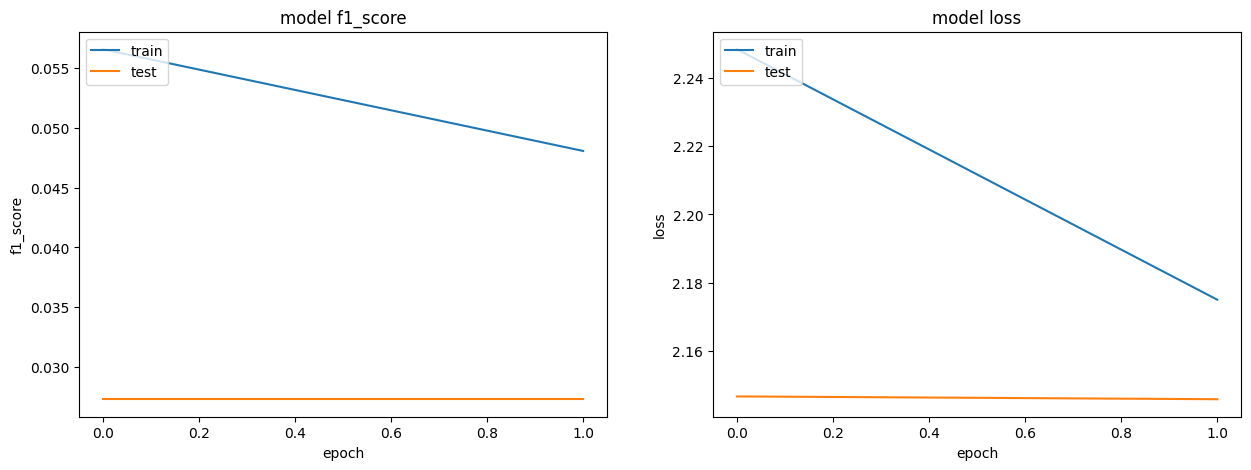

In [31]:
for combined in [history[-1]]:
    # summarize history for metric
    plt.figure(figsize=(15,5))
    plt.subplot(121)
    plt.plot(combined[metric_name])
    plt.plot(combined[metric_val])
    plt.title('model %s' % metric_name)
    plt.ylabel(metric_name)
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='upper left')

    # summarize history for loss
    plt.subplot(122)
    plt.plot(combined['loss'])
    plt.plot(combined['val_loss'])
    plt.title('model loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='upper left')
    plt.show()

In [32]:
# This code is taken from Lab 6

from itertools import combinations
from scipy import stats

# Survival function (1 - cdf): yields p-value from test statistic
# For instance, 3.841 would yield p = 0.05
chi2_p_value = stats.chi2.sf

def mcnemar_table(y_target, y_model1, y_model2):
    table = np.zeros((2, 2))
    for y, yhat1, yhat2 in zip(y_target, y_model1, y_model2):
        index1 = (1 if yhat1 == y else 0)
        index2 = (1 if yhat2 == y else 0)
        table[index1, index2] += 1
    return table

def mcnemar(table, corrected = True, exact = False):
    b = table[0, 1]
    c = table[1, 0]

    # Use a binomial test when appropriate
    if exact:
        n_min, n_max = sorted([b, c])
        p = (2 * stats.binom.cdf(n_min, n_min + n_max, 0.5) - 
            stats.binom.pmf(n_min, n_min + n_max, 0.5))
        return None, p

    if corrected:
        # Continuity correction from Edwards (1948)
        chi2 = ((abs(b - c) - 1) ** 2) / (b + c)
    else:
        # Original test statistic
        chi2 = ((b - c) ** 2) / (b + c)
    p = chi2_p_value(chi2, df = 1)
    return chi2, p

def mcnemar_test(y_target, model1, model2):
    table = mcnemar_table(y_target = y_target, y_model1 = model1, y_model2 = model2)
    print(table)
    n = table[0, 1] + table[1, 0]
    return mcnemar(table, corrected = True, exact = n < 25)

def test_models(y_test, alpha, models, names):
    assert(len(models) == len(names))
    for a, b in combinations(range(len(models)), 2):
        model1, name1, model2, name2 = (models[a], names[a], models[b], names[b])
        chi2, p = mcnemar_test(y_test, model1, model2)
        if chi2 is None:
            print("p = %0.10f for %s and %s so result is%s significantly different" %
                (p, name1, name2, "n't" if p > alpha else ""))
        else:
            print("\u03c7\u00b2 = %0.4f, p = %0.10f for %s and %s so result is%s significantly different" %
                (chi2, p, name1, name2, "n't" if p > alpha else ""))

In [33]:
test_models(y_test_argmax, 0.05, yhat_argmaxs, model_names)

[[4308.  838.]
 [1368. 1486.]]
χ² = 126.8545, p = 0.0000000000 for RNN and Transformer so result is significantly different
[[4468.  678.]
 [1177. 1677.]]
χ² = 133.6949, p = 0.0000000000 for RNN and Transformer modified so result is significantly different
[[4409.  737.]
 [1863.  991.]]
χ² = 486.7788, p = 0.0000000000 for RNN and CNN so result is significantly different
[[4409.  737.]
 [1863.  991.]]
χ² = 486.7788, p = 0.0000000000 for RNN and CNN tuned so result is significantly different
[[4409.  737.]
 [1863.  991.]]
χ² = 486.7788, p = 0.0000000000 for RNN and Transformer Attention II so result is significantly different
[[4534. 1142.]
 [1111. 1213.]]
χ² = 0.3995, p = 0.5273644539 for Transformer and Transformer modified so result isn't significantly different
[[4687.  989.]
 [1585.  739.]]
χ² = 137.5389, p = 0.0000000000 for Transformer and CNN so result is significantly different
[[4687.  989.]
 [1585.  739.]]
χ² = 137.5389, p = 0.0000000000 for Transformer and CNN tuned so result

Most results were significant, aside from the models that did not train, as shown in the confusion matrices below.

In [34]:
# This code is taken from Lab 6
%matplotlib inline

def compare_models(y_test, yhats, model_names, fig_size=(15,5), labels='auto'):
    ''' Plot confusion matrices for each model, with names
    '''
    plt.figure(figsize=fig_size)

    # plot confusion matrices 
    num_plots = len(yhats)
    i = 1
    for yhat in yhats:
        acc = mt.f1_score(y_test, yhat, average = "macro")

        cm = mt.confusion_matrix(y_test,yhat)
        cm = cm/np.sum(cm,axis=1)[:,np.newaxis]
        
        plt.subplot(1,num_plots,i)
        
        sns.heatmap(cm, annot=True, fmt='.2f',xticklabels=labels, yticklabels=labels)
        plt.title(f'{model_names[i - 1]}: {acc:.4f}')
        i += 1

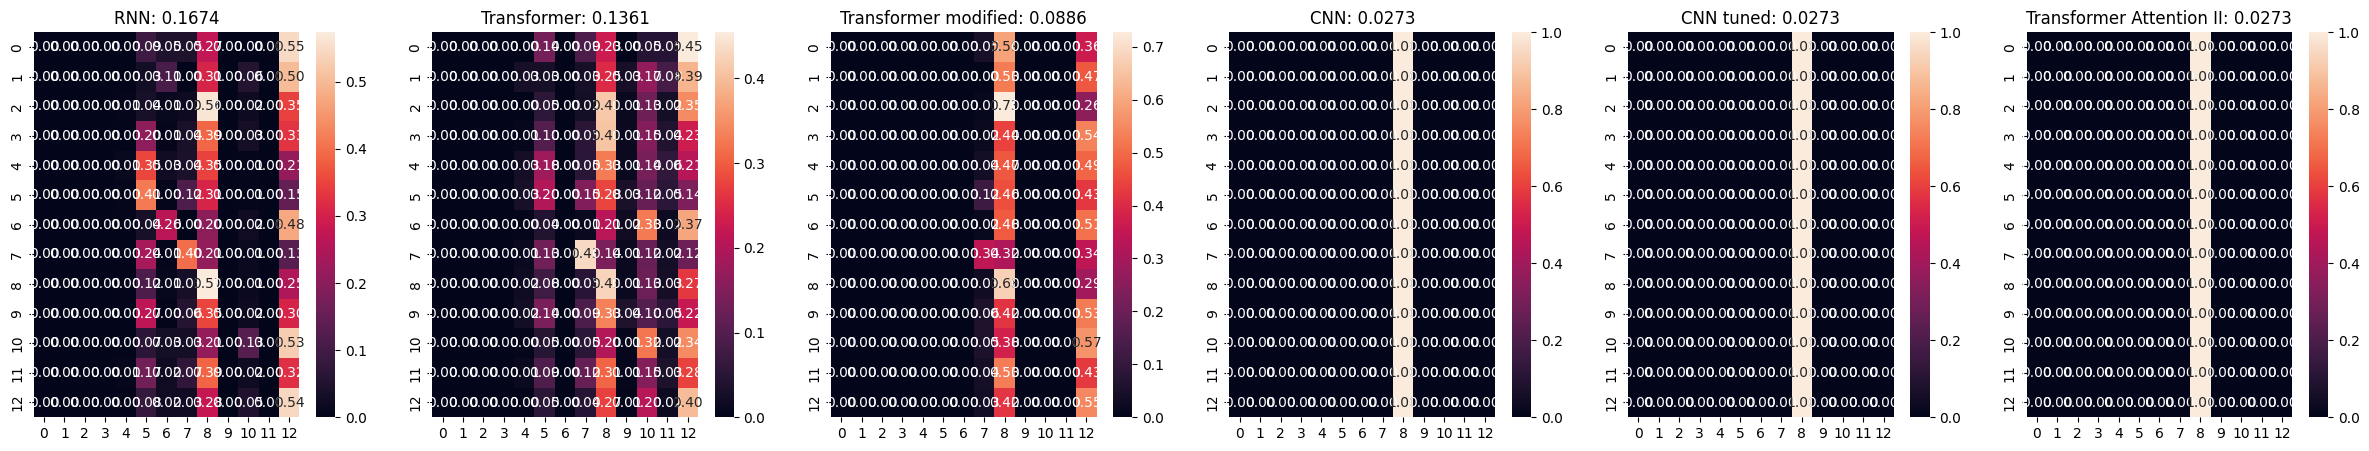

In [35]:
compare_models(y_test_argmax, yhat_argmaxs, model_names, fig_size = (30, 5))

The recurrent network appeared to be surprisingly effective in terms of performance and efficiency training quickly. While the transformer was also very effective, it took much longer to train it compared to the recurrent network.

Ultimately, many of our models still largely focused on the plurality classes.If we had more time, we would want to do further analysis on how these trends would continue to hold with more training as well as further explore the hyperparameters that led many of the models not to train at all.